**Retail Sales Data Analysis**

**Task 1 – Exploratory Data Analysis**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Data Loading**

In [ ]:
df=pd.read_csv("/content/retail_sales_dataset.csv")

**Dataset Overview**

In [ ]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


**Dataset Dimensions**

In [ ]:
df.shape

(1000, 9)

**Data Information**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


**Data Cleaning – Duplicate Check**

In [ ]:
df.duplicated().sum()

np.int64(0)

**Descriptive Statistics**

In [ ]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


**Date Conversion and Feature Creation**

In [ ]:
df["Date"]=pd.to_datetime(df["Date"])


In [ ]:
df["Month"]=df["Date"].dt.month

In [ ]:
df[["Date","Month"]].head()

,Date,Month
0,2023-11-24,11
1,2023-02-27,2
2,2023-01-13,1
3,2023-05-21,5
4,2023-05-06,5


**Monthly Sales Analysis**

In [ ]:
monthly_sales = df.groupby("Month")["Total Amount"].sum()
monthly_sales

,Total Amount
Month,
1,36980
2,44060
3,28990
4,33870
5,53150
6,36715
7,35465
8,36960
9,23620


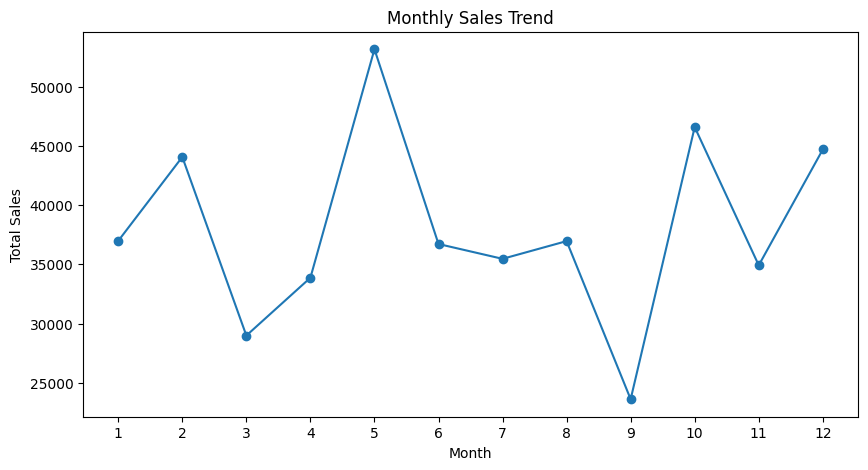

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.title("Monthly Sales Trend")
plt.xticks(range(1, 13))
plt.show()

**Sales by Product Category**

In [ ]:
category_sales = df.groupby("Product Category")["Total Amount"].sum()
category_sales

,Total Amount
Product Category,
Beauty,143515
Clothing,155580
Electronics,156905


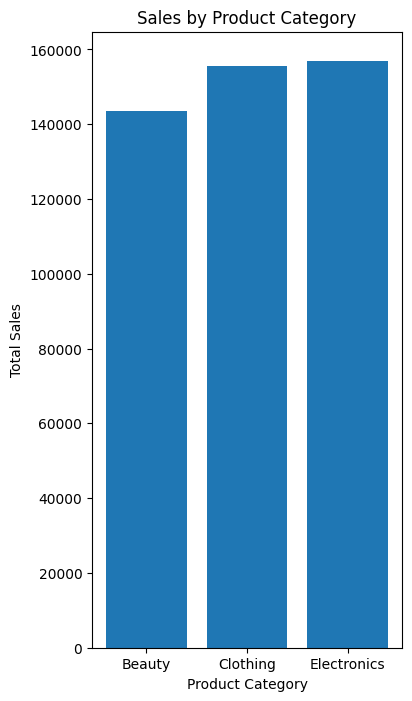

In [ ]:
plt.figure(figsize=(4,8))
plt.bar(category_sales.index, category_sales.values)
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.title("Sales by Product Category")
plt.show()

**Sales by Gender**

In [ ]:
gender_sales=df.groupby("Gender")["Total Amount"].sum()
gender_sales

,Total Amount
Gender,
Female,232840
Male,223160


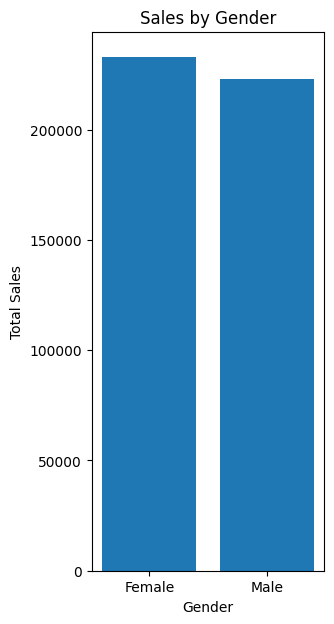

In [ ]:
plt.figure(figsize=(3,7))
plt.bar(gender_sales.index, gender_sales.values)
plt.xlabel("Gender")
plt.ylabel("Total Sales")
plt.title("Sales by Gender")
plt.show()

**Customer Age Distribution**

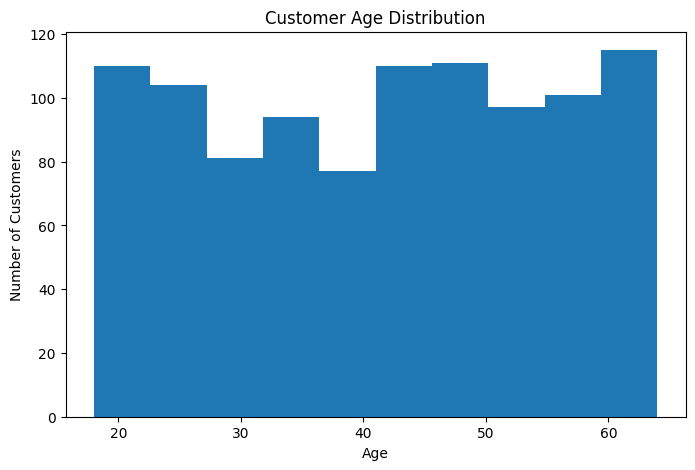

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df["Age"], bins=10)
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.title("Customer Age Distribution")
plt.show()

**Sales by Age Group**

In [ ]:
df["Age Group"] = pd.cut(
    df["Age"],
    bins=[17, 25, 35, 45, 55, 65],
    labels=["18-25", "26-35", "36-45", "46-55", "56-65"]
)

age_group_sales = df.groupby("Age Group", observed=True)["Total Amount"].sum()
age_group_sales

,Total Amount
Age Group,
18-25,84550
26-35,98480
36-45,91870
46-55,100690
56-65,80410


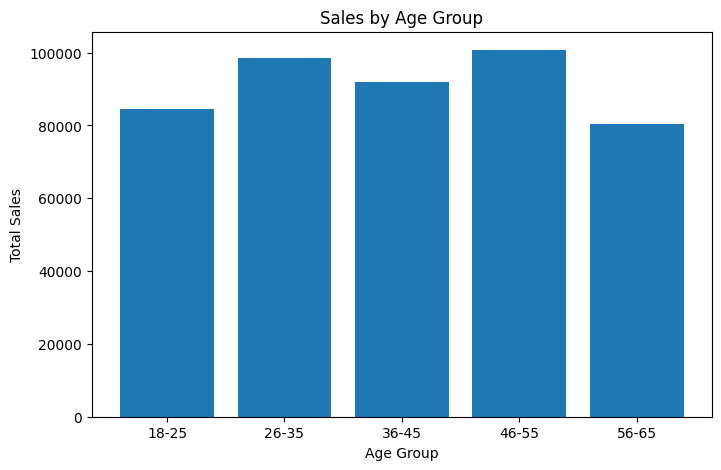

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(age_group_sales.index, age_group_sales.values)
plt.xlabel("Age Group")
plt.ylabel("Total Sales")
plt.title("Sales by Age Group")
plt.show()

**Top Product Categories by Sales**

In [ ]:
top_products = (
    df.groupby("Product Category")["Total Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

,Total Amount
Product Category,
Electronics,156905
Clothing,155580
Beauty,143515


**Quantity Sold by Product Category**

In [ ]:
category_quantity = df.groupby("Product Category")["Quantity"].sum()
category_quantity

,Quantity
Product Category,
Beauty,771
Clothing,894
Electronics,849


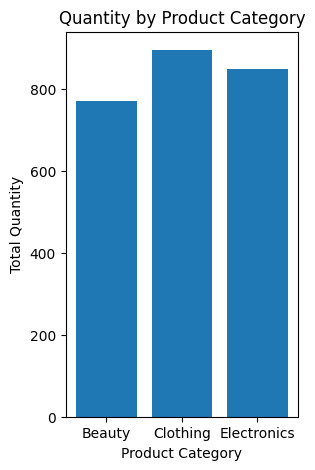

In [ ]:
plt.figure(figsize=(3,5))
plt.bar(category_quantity.index, category_quantity.values)
plt.xlabel("Product Category")
plt.ylabel("Total Quantity")
plt.title("Quantity by Product Category")
plt.show()

**Price and Quantity Correlation**

In [ ]:
price_quantity_corr = df["Price per Unit"].corr(df["Quantity"])
price_quantity_corr

np.float64(0.017501280115958688)

**Correlation Matrix**

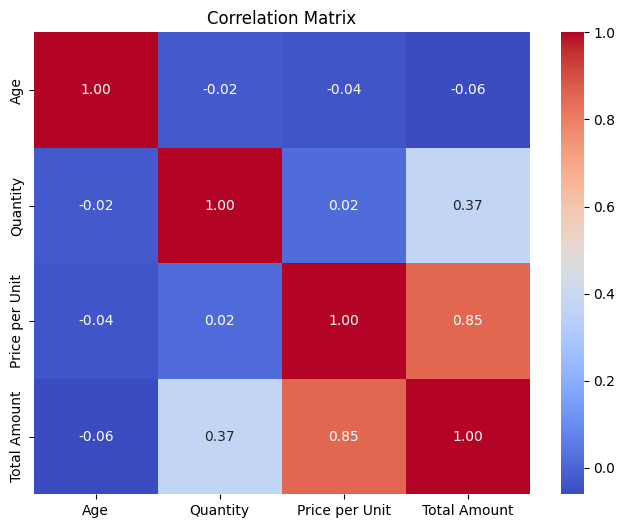

In [ ]:
correlation = df[["Age", "Quantity", "Price per Unit", "Total Amount"]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

**Key Findings / Observations**

1. Electronics had the total sales compared to the other two product categories.

2. Clothing had the quantity sold among all product categories.

Female customers generated higher sales than male customers.

3. The 46–55 age group generated the sales.

4. Price per Unit has a positive relationship with Total Amount (0.85).

5. Quantity has a positive relationship with Total Amount (0.37).

6. Price, per Unit and Quantity have no correlation (0.02).




**Business Recommendations**

1. Focus, on Electronics: Electronics has the total sales. Therefore the business should keep an amount of stock and promote the best-selling Electronics items.

2. Improve Clothing Sales: Clothing has the highest quantity sold. The business can offer promotions and bundle deals to raise Clothing sales value.

3. Target High-Sales Customers: The 46–55 age group and female customers produced sales. Targeted offers and marketing campaigns should be aimed at these High-Sales Customers.